In [1]:
!pip install seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame
print("Shape:", df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


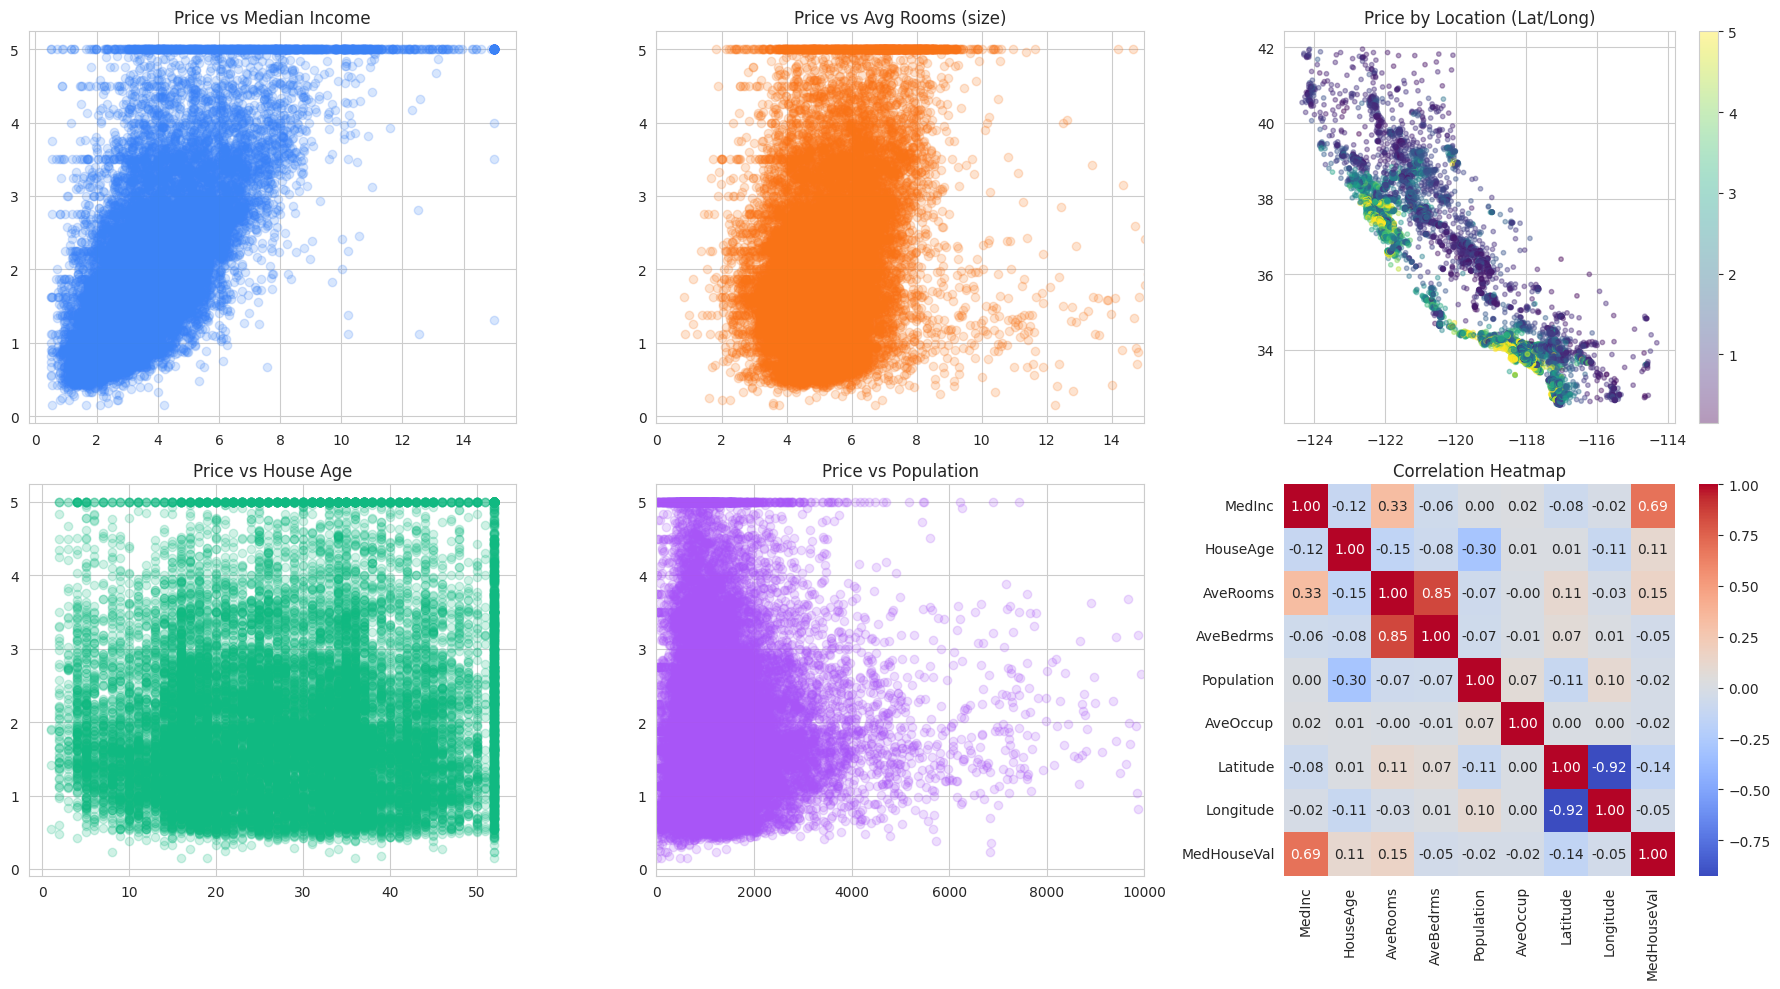

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].scatter(df["MedInc"], df["MedHouseVal"], alpha=0.2, color="#3b82f6")
axes[0, 0].set_title("Price vs Median Income")

axes[0, 1].scatter(df["AveRooms"], df["MedHouseVal"], alpha=0.2, color="#f97316")
axes[0, 1].set_xlim(0, 15)
axes[0, 1].set_title("Price vs Avg Rooms (size)")

sc = axes[0, 2].scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"],
                         cmap="viridis", alpha=0.4, s=10)
plt.colorbar(sc, ax=axes[0, 2])
axes[0, 2].set_title("Price by Location (Lat/Long)")

axes[1, 0].scatter(df["HouseAge"], df["MedHouseVal"], alpha=0.2, color="#10b981")
axes[1, 0].set_title("Price vs House Age")

axes[1, 1].scatter(df["Population"], df["MedHouseVal"], alpha=0.2, color="#a855f7")
axes[1, 1].set_xlim(0, 10000)
axes[1, 1].set_title("Price vs Population")

corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 2])
axes[1, 2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

print(corr["MedHouseVal"].sort_values(ascending=False))

In [4]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# All features here are numeric — scaling is enough, no categorical encoding needed
scaler = StandardScaler()

In [17]:
rf_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42)),
])

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 15, 20],   # removed None
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],   # removed None
}

search = RandomizedSearchCV(
    rf_pipe, param_distributions=param_dist, n_iter=10, cv=3,
    scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1, verbose=2,
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)

best_model = search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20}
Best CV RMSE: 0.5010356189025896


In [18]:
preds = best_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE  : {mae:.4f}  (in $100,000s)")
print(f"RMSE : {rmse:.4f}  (in $100,000s)")
print(f"R2   : {r2:.4f}")

MAE  : 0.3289  (in $100,000s)
RMSE : 0.4959  (in $100,000s)
R2   : 0.8124


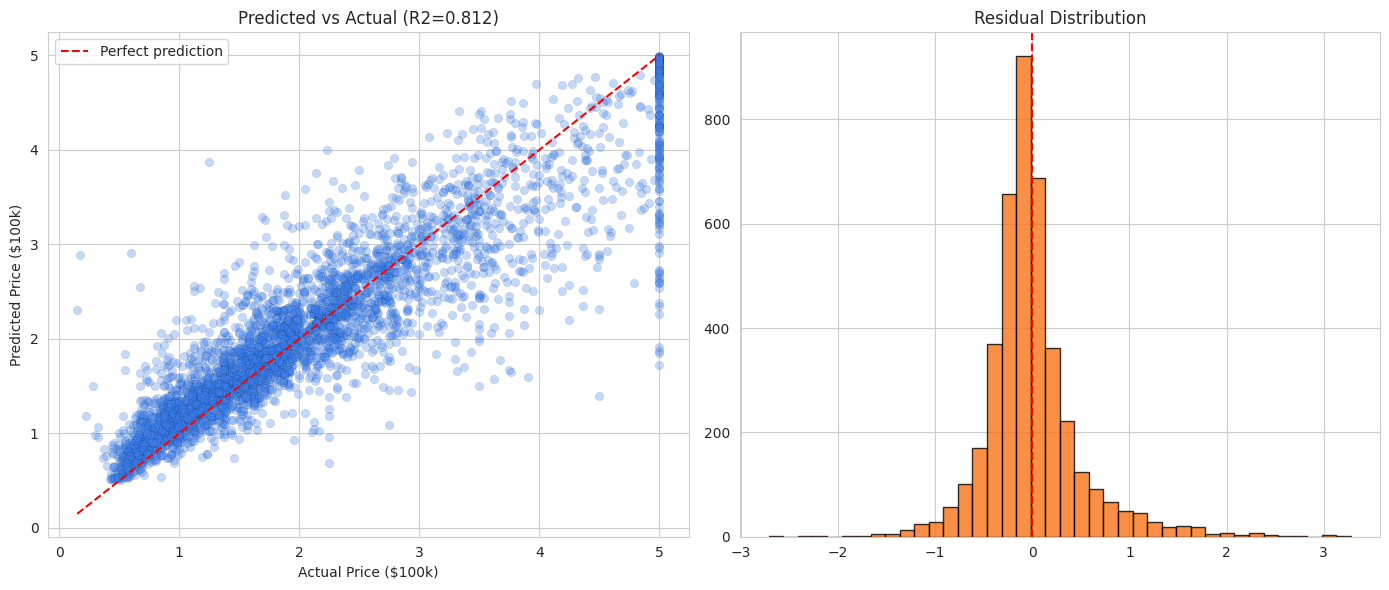

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, preds, alpha=0.3, color="#3b82f6", edgecolor="k", linewidth=0.2)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual Price ($100k)")
axes[0].set_ylabel("Predicted Price ($100k)")
axes[0].set_title(f"Predicted vs Actual (R2={r2:.3f})")
axes[0].legend()

residuals = y_test.values - preds
axes[1].hist(residuals, bins=40, color="#f97316", edgecolor="black", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

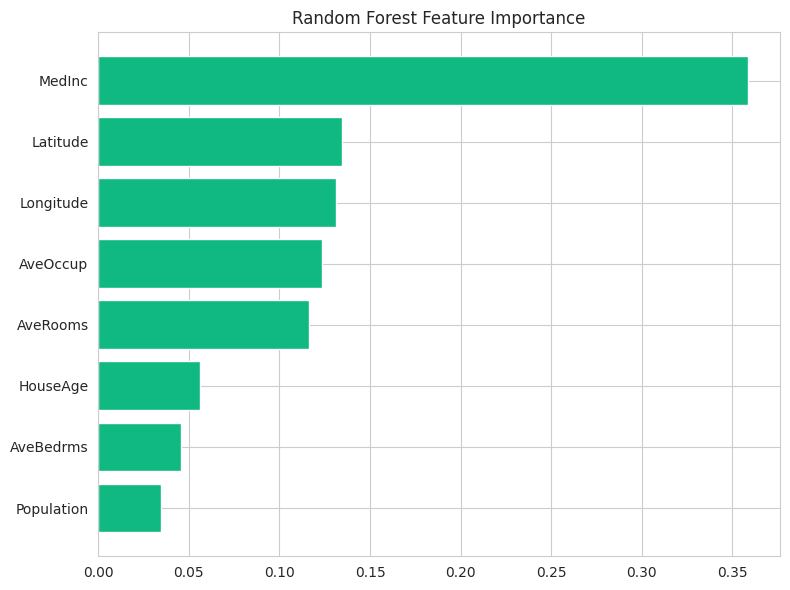

In [20]:
importances = best_model.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": X.columns, "importance": importances}).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(imp_df["feature"], imp_df["importance"], color="#10b981")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()